# 📊 Walmart Store Sales — Análise e Previsão de Vendas

## 🎯 Objetivo do Projeto

Este projeto tem como objetivo analisar o histórico de vendas de lojas do Walmart e desenvolver modelos de Machine Learning capazes de prever as vendas semanais.

Além da previsão, a análise busca compreender os principais padrões presentes nos dados, investigando diferenças entre lojas e departamentos, comportamento das vendas ao longo do tempo e possíveis relações com feriados, promoções e variáveis econômicas.

O projeto foi desenvolvido com foco em aplicar, na prática, conceitos de **Análise Exploratória de Dados (EDA), tratamento de dados, Feature Engineering e Machine Learning para dados temporais**.

## 🔎 Etapas do Projeto

O desenvolvimento foi dividido nas seguintes etapas:

1. **Preparação dos dados**
   - carregamento e integração das bases;
   - análise da estrutura dos dados;
   - tratamento de valores ausentes e preparação das variáveis.

2. **Análise Exploratória de Dados (EDA)**
   - análise da evolução das vendas ao longo do tempo;
   - comparação entre lojas e departamentos;
   - investigação do impacto de feriados;
   - análise das variáveis de MarkDown;
   - análise de temperatura, preço dos combustíveis, CPI e desemprego.

3. **Feature Engineering**
   - criação de variáveis temporais;
   - identificação de períodos de feriados;
   - criação de variáveis baseadas no histórico de vendas, como lags e média móvel.

4. **Modelagem e validação**
   - separação dos dados respeitando a ordem temporal;
   - criação de um modelo baseline para comparação;
   - treinamento dos modelos Random Forest e XGBoost;
   - avaliação utilizando MAE, RMSE e R²;
   - seleção do modelo com melhor desempenho.

5. **Análise dos erros**
   - identificação das lojas e departamentos com maiores erros de previsão;
   - comparação do desempenho do modelo entre períodos normais e o Labor Day.

## 💡 Pergunta Principal

> **É possível utilizar o histórico de vendas e as características das lojas para prever as vendas semanais e identificar situações em que essas previsões se tornam mais difíceis?**

In [362]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [363]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")
df_features = pd.read_csv("features.csv")
df_stores = pd.read_csv("stores.csv")

In [364]:
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("Features shape:", df_features.shape)
print("Stores shape:", df_stores.shape)

Train shape: (421570, 5)
Test shape: (115064, 4)
Features shape: (8190, 12)
Stores shape: (45, 3)


In [365]:
print("="*50)
print("Informação das stores (lojas) \n")
print(f"{df_stores.info()}")
print("="*50)

print("="*50)
print("Informação das features (características) \n")
print(f"{df_features.info()}")
print("="*50)

print("="*50)
print("Informação do train (treino) \n")
print(f"{df_train.info()}")
print("="*50)

print("="*50)
print("Informação do test (teste) \n")
print(f"{df_test.info()}")
print("="*50)

Informação das stores (lojas) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB
None
Informação das features (características) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CP

In [366]:
print("Features Info")
print(df_features.head())
print("Stores Info")
print(df_stores.head())
print("Train Info")
print(df_train.head())
print("test Info")
print(df_test.head())


Features Info
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN  211.096358         8.106      False  
1        NaN        NaN        NaN  211.242170         8.106       True  
2        NaN        NaN        NaN  211.289143         8.106      False  
3        NaN        NaN        NaN  211.319643         8.106      False  
4        NaN        NaN        NaN  211.350143         8.106      False  
Stores Info
   Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392
3      4    A  

In [367]:
df_features['Date'] = pd.to_datetime(df_features['Date'])
df_features['Year'] = df_features['Date'].dt.year
df_features['Month'] = df_features['Date'].dt.month
df_features['Day'] = df_features['Date'].dt.day


In [368]:
df_train['Date'] = pd.to_datetime(df_train['Date'])
df_test['Date'] = pd.to_datetime(df_test['Date'])

print(df_train["Date"].dtype)
print(df_features["Date"].dtype)

datetime64[ns]
datetime64[ns]


In [369]:
(df_features.isnull().sum() / len(df_features) * 100).round(2)

,0
Store,0.00
Date,0.00
Temperature,0.00
Fuel_Price,0.00
MarkDown1,50.77
MarkDown2,64.33
MarkDown3,55.89
MarkDown4,57.70
MarkDown5,50.55
CPI,7.14


In [370]:
antes_markdown = df_features[df_features["Date"] < "2011-11-01"]
depois_markdown = df_features[df_features["Date"] >= "2011-11-01"]

In [371]:
antes_markdown[["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]].isnull().sum()

,0
MarkDown1,4095
MarkDown2,4095
MarkDown3,4095
MarkDown4,4095
MarkDown5,4095


In [372]:
depois_markdown[["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]].isnull().sum()

,0
MarkDown1,63
MarkDown2,1174
MarkDown3,482
MarkDown4,631
MarkDown5,45


In [373]:
cols_markdown = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
antes_markdown[cols_markdown].isnull().mean() * 100

,0
MarkDown1,100.0
MarkDown2,100.0
MarkDown3,100.0
MarkDown4,100.0
MarkDown5,100.0


In [374]:
depois_markdown[cols_markdown].isnull().mean() * 100

,0
MarkDown1,1.538462
MarkDown2,28.669109
MarkDown3,11.770452
MarkDown4,15.409035
MarkDown5,1.098901


### Valores ausentes — MarkDown

As variáveis `MarkDown1` a `MarkDown5` apresentam uma quantidade elevada de valores ausentes quando considerada toda a base.

Entretanto, a documentação informa que os dados de markdown passaram a estar disponíveis somente a partir de novembro de 2011.

A análise temporal confirmou essa característica: antes desse período, 100% dos registros das cinco variáveis são ausentes.

Após novembro de 2011, a disponibilidade dos dados aumenta significativamente, embora ainda existam valores ausentes, principalmente em `MarkDown2`, `MarkDown3` e `MarkDown4`.

Dessa forma, os valores ausentes não serão interpretados automaticamente como ausência de promoções, pois `NaN` representa indisponibilidade da informação e não necessariamente valor zero.

In [375]:
# Verificando CPI e Unemployment
valores_cpi = df_features.loc[df_features["CPI"].isnull(), "Date" ].value_counts().sort_index()
valores_unemployment = df_features.loc[df_features["Unemployment"].isnull(), "Date"].value_counts().sort_index()

print(f"Valores ausentes em CPI: \n{valores_cpi}")
print(f"Valores ausentes em Unemployment: \n{valores_unemployment}")

Valores ausentes em CPI: 
Date
2013-05-03    45
2013-05-10    45
2013-05-17    45
2013-05-24    45
2013-05-31    45
2013-06-07    45
2013-06-14    45
2013-06-21    45
2013-06-28    45
2013-07-05    45
2013-07-12    45
2013-07-19    45
2013-07-26    45
Name: count, dtype: int64
Valores ausentes em Unemployment: 
Date
2013-05-03    45
2013-05-10    45
2013-05-17    45
2013-05-24    45
2013-05-31    45
2013-06-07    45
2013-06-14    45
2013-06-21    45
2013-06-28    45
2013-07-05    45
2013-07-12    45
2013-07-19    45
2013-07-26    45
Name: count, dtype: int64


In [376]:
(df_features["CPI"].isnull() == df_features["Unemployment"].isnull()).all()

np.True_

### Valores ausentes — CPI e Unemployment

As variáveis `CPI` e `Unemployment` apresentam 585 valores ausentes cada, correspondendo a aproximadamente 7,14% da base.

A análise mostrou que os valores ausentes ocorrem exatamente nos mesmos registros para ambas as variáveis.

Além disso, a ausência está concentrada entre 03/05/2013 e 26/07/2013. Em cada uma dessas 13 semanas existem 45 registros ausentes, quantidade equivalente ao número de lojas presentes na base.

Esse padrão indica que a ausência de `CPI` e `Unemployment` é temporal e sistemática, afetando todas as lojas em determinadas semanas, e não um conjunto aleatório de registros.

In [377]:
display(df_train)
display(df_features)
display(df_stores)
display(df_test)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Year,Month,Day
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,2010,2,5
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,2010,2,12
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,2010,2,19
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,2010,2,26
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,2010,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False,2013,6,28
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False,2013,7,5
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False,2013,7,12
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False,2013,7,19


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False
...,...,...,...,...
115059,45,98,2013-06-28,False
115060,45,98,2013-07-05,False
115061,45,98,2013-07-12,False
115062,45,98,2013-07-19,False


## Seguindo para o EDA

In [378]:
df = pd.merge(
    df_train,
    df_features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

In [379]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Day
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2,12
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2,19
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2,26
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,2012,9,28
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,2012,10,5
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,2012,10,12
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,2012,10,19


In [380]:
print(df.shape)
print(df.head())
print(df.columns)

(421570, 17)
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50      False        42.31       2.572   
1      1     1 2010-02-12      46039.49       True        38.51       2.548   
2      1     1 2010-02-19      41595.55      False        39.93       2.514   
3      1     1 2010-02-26      19403.54      False        46.63       2.561   
4      1     1 2010-03-05      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment  Year  Month  Day  
0         8.106  2010      2    5  
1      

In [381]:
df_merge = pd.merge(df, df_stores, on="Store", how="left")
df_merge

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Day,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2,5,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2,12,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2,19,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2,26,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3,5,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,2012,9,28,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,2012,10,5,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,2012,10,12,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,2012,10,19,B,118221


In [382]:
print(df.shape)
print(df_merge.shape)

(421570, 17)
(421570, 19)


## Desempenho das lojas

In [383]:
# Desempenho das lojas
df_desempenho = (df_merge.groupby(["Store", "Date"])["Weekly_Sales"].sum().sort_values(ascending=False).reset_index())
df_desempenho

,Store,Date,Weekly_Sales
0,14,2010-12-24,3818686.45
1,20,2010-12-24,3766687.43
2,10,2010-12-24,3749057.69
3,4,2011-12-23,3676388.98
4,13,2010-12-24,3595903.20
...,...,...,...
6430,33,2011-12-02,220060.35
6431,33,2010-12-31,219804.85
6432,33,2011-12-30,215359.21
6433,33,2010-10-29,213538.32


In [384]:
# maior venda semanal média de cada loja
df_media_lojas = (df_desempenho.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False).reset_index())
df_media_lojas["Weekly_Sales"] = df_media_lojas["Weekly_Sales"].round(2)
df_media_lojas.style.format({"Weekly_Sales": "$ {:,.2f}"})


,Store,Weekly_Sales
0,20,"$ 2,107,676.87"
1,4,"$ 2,094,712.96"
2,14,"$ 2,020,978.40"
3,13,"$ 2,003,620.31"
4,2,"$ 1,925,751.34"
5,10,"$ 1,899,424.57"
6,27,"$ 1,775,216.20"
7,6,"$ 1,564,728.19"
8,1,"$ 1,555,264.40"
9,39,"$ 1,450,668.13"


In [385]:
df_media_lojas = df_media_lojas.rename(columns={"Weekly_Sales": "Average_Weekly_Sales"})

In [386]:
df_media_lojas = pd.merge(df_media_lojas, df_stores, on="Store", how="left")
df_media_lojas.head(10)

,Store,Average_Weekly_Sales,Type,Size
0,20,2107676.87,A,203742
1,4,2094712.96,A,205863
2,14,2020978.40,A,200898
3,13,2003620.31,A,219622
4,2,1925751.34,A,202307
5,10,1899424.57,B,126512
6,27,1775216.20,A,204184
7,6,1564728.19,A,202505
8,1,1555264.40,A,151315
9,39,1450668.13,A,184109


In [387]:
df_media_lojas[["Size", "Average_Weekly_Sales"]].corr()

,Size,Average_Weekly_Sales
Size,1.000000,0.846161
Average_Weekly_Sales,0.846161,1.000000


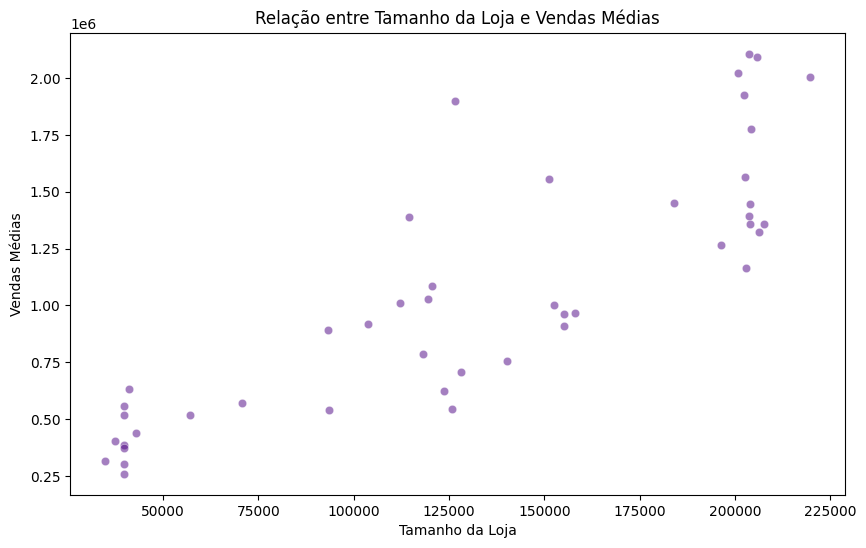

In [388]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_media_lojas, x="Size", y="Average_Weekly_Sales", alpha=0.5, color="indigo")
plt.title("Relação entre Tamanho da Loja e Vendas Médias")
plt.xlabel("Tamanho da Loja")
plt.ylabel("Vendas Médias")
plt.show()

Foi identificada uma forte associação positiva entre o tamanho das lojas e o volume médio de vendas semanais, com correlação de aproximadamente 0,85. O gráfico de dispersão reforça essa relação, indicando que lojas de maior porte tendem a apresentar maiores volumes de vendas. Entretanto, a relação não é perfeita, sugerindo que outros fatores também contribuem para o desempenho das unidades.

In [389]:
df_media_tipos = df_media_lojas.groupby("Type")["Average_Weekly_Sales"].mean().sort_values(ascending=False).reset_index()
df_media_tipos["Average_Weekly_Sales"] = df_media_tipos["Average_Weekly_Sales"].round(2)
df_media_tipos.style.format({"Average_Weekly_Sales": "$ {:,.2f}"})

,Type,Average_Weekly_Sales
0,A,"$ 1,376,673.47"
1,B,"$ 822,994.95"
2,C,"$ 472,614.83"


In [390]:
df_media_lojas.groupby("Type")["Size"].mean().sort_values(ascending=False).reset_index()

,Type,Size
0,A,177247.727273
1,B,101190.705882
2,C,40541.666667


As lojas do tipo A apresentam a maior venda semanal média, seguidas pelos tipos B e C. Entretanto, essa diferença coincide com diferenças relevantes no porte das lojas: as unidades do tipo A também apresentam o maior tamanho médio, enquanto as do tipo C são consideravelmente menores. Como o tamanho da loja apresenta forte correlação positiva com as vendas semanais médias (r ≈ 0,85), parte das diferenças observadas entre os tipos pode estar associada ao porte das unidades. Portanto, não é adequado atribuir o maior desempenho exclusivamente ao tipo da loja.

In [391]:
df_merge

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Day,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2,5,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2,12,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2,19,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2,26,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3,5,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,2012,9,28,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,2012,10,5,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,2012,10,12,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,2012,10,19,B,118221


## Desempenho dos departamentos

In [392]:
# Quais departamentos apresentam maior desempenho médio?
df_media_dept = df_merge.groupby("Dept")["Weekly_Sales"].mean().sort_values(ascending=False).reset_index()
df_media_dept = df_media_dept.rename(columns={"Weekly_Sales": "Average_Weekly_Sales"})
df_media_dept["Average_Weekly_Sales"] = df_media_dept["Average_Weekly_Sales"].round(2)
df_media_dept.style.format({"Average_Weekly_Sales": "$ {:,.2f}"})

,Dept,Average_Weekly_Sales
0,92,"$ 75,204.87"
1,95,"$ 69,824.42"
2,38,"$ 61,090.62"
3,72,"$ 50,566.52"
4,65,"$ 45,441.71"
5,90,"$ 45,232.08"
6,40,"$ 44,900.70"
7,2,"$ 43,607.02"
8,91,"$ 33,687.91"
9,94,"$ 33,405.88"


In [393]:
df_quantidade_lojas = (df_merge.groupby("Dept")["Store"].nunique())

In [394]:
# Em quantas lojas diferentes cada departamento aparece?

df_quantidade_lojas.loc[[92, 95, 38, 72, 65, 90, 40, 2, 91, 94, 13]]

,Store
Dept,
92,45
95,45
38,45
72,45
65,1
90,45
40,45
2,45
91,45


O Departamento 92 apresentou a maior venda média, com aproximadamente US$ 75,2 mil por observação, seguido pelos departamentos 95 e 38. Os principais departamentos do ranking estão presentes nas 45 lojas analisadas, indicando que o resultado não está restrito a poucas unidades. O Departamento 65 constitui uma exceção: apesar de apresentar média elevada, está presente em apenas uma loja, devendo seu desempenho ser interpretado com cautela.

In [395]:
# Como o volume total de vendas da rede evoluiu ao longo do tempo?
volume_total = df_merge.groupby("Date")["Weekly_Sales"].sum()
volume_total

,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30
...,...
2012-09-28,43734899.40
2012-10-05,47566639.31
2012-10-12,46128514.25


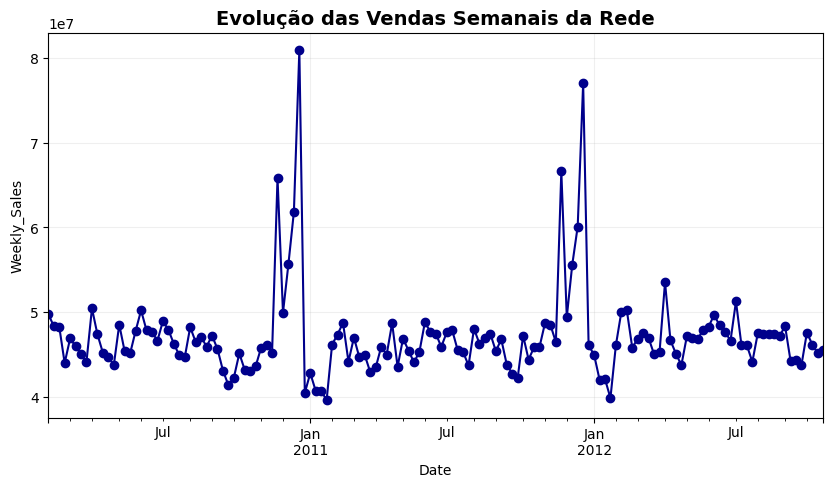

In [396]:
plt.figure(figsize=(10, 5))
volume_total.sort_index().plot(kind='line', marker='o', color='darkblue')
plt.title('Evolução das Vendas Semanais da Rede', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Weekly_Sales')
plt.grid(alpha=0.2)
plt.show()

Análise temporal das vendas: As vendas semanais apresentam comportamento relativamente estável durante grande parte do período analisado, sem evidência visual de uma tendência contínua de crescimento ou queda. Entretanto, observa-se forte sazonalidade no final do ano, com aumentos expressivos nas semanas que antecedem o período de Natal e queda acentuada posteriormente. Thanksgiving também coincide com um período de forte elevação das vendas. Já nos períodos associados ao Super Bowl e Labor Day, não são observadas variações de magnitude comparável no gráfico geral da rede. Esses resultados sugerem que determinados períodos de fim de ano estão associados a mudanças relevantes no comportamento das vendas.

## Desempenho por Feriados

In [397]:
# As semanas classificadas como feriado apresentam vendas maiores do que as semanas comuns?

df_feriado = df_merge.groupby("IsHoliday")["Weekly_Sales"].mean().sort_values(ascending=False).reset_index()
df_feriado

,IsHoliday,Weekly_Sales
0,True,17035.823187
1,False,15901.445069


In [398]:
df_vendas_semanais = df_merge.groupby(["Date", "IsHoliday"])["Weekly_Sales"].sum().sort_values(ascending=False).reset_index()
df_vendas_semanais

,Date,IsHoliday,Weekly_Sales
0,2010-12-24,False,80931415.60
1,2011-12-23,False,76998241.31
2,2011-11-25,True,66593605.26
3,2010-11-26,True,65821003.24
4,2010-12-17,False,61820799.85
...,...,...,...
138,2011-01-14,False,40673678.04
139,2011-01-21,False,40654648.03
140,2010-12-31,True,40432519.00
141,2012-01-27,False,39834974.67


In [399]:
df_vendas_semanais.groupby("IsHoliday")["Weekly_Sales"].mean().sort_values(ascending=False).reset_index()

,IsHoliday,Weekly_Sales
0,True,5.052996e+07
1,False,4.685654e+07


In [400]:
# Todos os feriados aumentam as vendas da mesma forma ou alguns têm efeito muito mais forte que outros?

feriados = {
    "2010-02-12": "Super Bowl",
    "2011-02-11": "Super Bowl",
    "2012-02-10": "Super Bowl",
    "2013-02-08": "Super Bowl",

    "2010-09-10": "Labor Day",
    "2011-09-09": "Labor Day",
    "2012-09-07": "Labor Day",
    "2013-09-06": "Labor Day",

    "2010-11-26": "Thanksgiving",
    "2011-11-25": "Thanksgiving",
    "2012-11-23": "Thanksgiving",
    "2013-11-29": "Thanksgiving",

    "2010-12-31": "Christmas",
    "2011-12-30": "Christmas",
    "2012-12-28": "Christmas",
    "2013-12-27": "Christmas"
}

feriados = {
    pd.to_datetime(data): nome
    for data,
    nome in feriados.items()
}

df_vendas_semanais["Holiday"] = df_vendas_semanais["Date"].map(feriados)

In [401]:
df_feriados = df_vendas_semanais.groupby("Holiday")["Weekly_Sales"].mean().sort_values(ascending=False).reset_index()
df_feriados

,Holiday,Weekly_Sales
0,Thanksgiving,6.620730e+07
1,Super Bowl,4.856076e+07
2,Labor Day,4.690923e+07
3,Christmas,4.323749e+07


Impacto dos feriados nas vendas: Após agregar as vendas na granularidade semanal, observou-se que semanas classificadas como feriado apresentam média de aproximadamente $50,5 milhões em vendas totais, contra $46,9 milhões em semanas comuns. Isso representa uma diferença de cerca de 7,8%, indicando uma associação positiva entre períodos de feriado e maior volume de vendas. Esse comportamento, entretanto, não é uniforme entre todos os feriados, já que a análise temporal mostrou que eventos como Thanksgiving apresentam picos muito mais expressivos do que Super Bowl e Labor Day.

## Promoções e MarkDowns

In [402]:
df_merge["HasMarkDown"] = df_merge[["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]].notna().any(axis=1)
df_merge

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Day,Type,Size,HasMarkDown
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2,5,A,151315,False
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2,12,A,151315,False
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2,19,A,151315,False
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2,26,A,151315,False
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3,5,A,151315,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,2012,9,28,B,118221,True
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,2012,10,5,B,118221,True
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,2012,10,12,B,118221,True
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,2012,10,19,B,118221,True


In [403]:
df_merge['HasMarkDown'].value_counts()

,count
HasMarkDown,
False,270138
True,151432


In [404]:
# A partir de novembro de 2011, semanas com informação de MarkDown apresentam vendas diferentes das semanas sem informação registrada?
df_markdown_periodo = df_merge[df_merge["Date"] >= "2011-11-01"]
df_markdown_periodo.groupby("HasMarkDown")["Weekly_Sales"].mean().sort_values(ascending=False).reset_index()

,HasMarkDown,Weekly_Sales
0,False,16471.071192
1,True,16177.015244


In [405]:
# Venda total de cada loja em cada semana
df_venda_total = df_merge.groupby(["Store", "Date"])["Weekly_Sales"].sum().sort_values(ascending=False).reset_index()
df_venda_total

,Store,Date,Weekly_Sales
0,14,2010-12-24,3818686.45
1,20,2010-12-24,3766687.43
2,10,2010-12-24,3749057.69
3,4,2011-12-23,3676388.98
4,13,2010-12-24,3595903.20
...,...,...,...
6430,33,2011-12-02,220060.35
6431,33,2010-12-31,219804.85
6432,33,2011-12-30,215359.21
6433,33,2010-10-29,213538.32


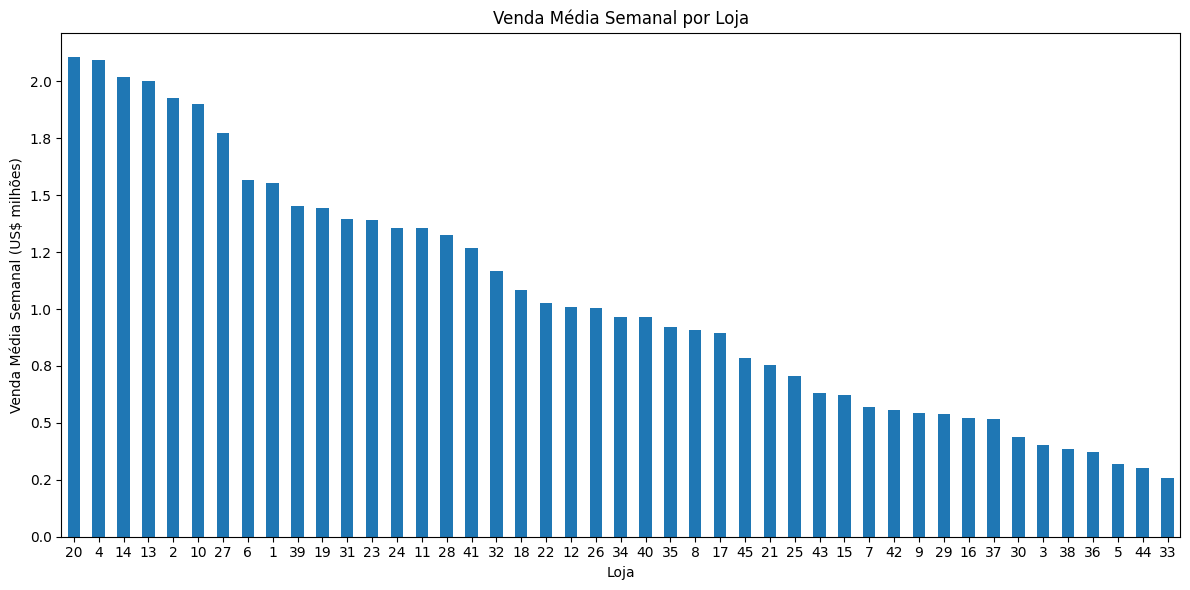

In [406]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Calcular a venda média semanal de cada loja
vendas_media_loja = (
    df_venda_total.groupby('Store')['Weekly_Sales']
    .mean()
    .sort_values(ascending=False)
)

# Criar o gráfico
plt.figure(figsize=(12, 6))

vendas_media_loja.plot(kind='bar')

plt.title('Venda Média Semanal por Loja')
plt.xlabel('Loja')
plt.ylabel('Venda Média Semanal (US$ milhões)')

# Exibir os valores do eixo Y em milhões
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x / 1_000_000:.1f}')
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [407]:
df_venda_markdown = pd.merge(df_venda_total, df_features, on=["Store", "Date"], how="left")
df_venda_markdown.shape

(6435, 16)

In [408]:
df_venda_markdown.head()

,Store,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Year,Month,Day
0,14,2010-12-24,3818686.45,30.59,3.141,NaN,NaN,NaN,NaN,NaN,182.544590,8.724,False,2010,12,24
1,20,2010-12-24,3766687.43,25.17,3.141,NaN,NaN,NaN,NaN,NaN,204.637673,7.484,False,2010,12,24
2,10,2010-12-24,3749057.69,57.06,3.236,NaN,NaN,NaN,NaN,NaN,126.983581,9.003,False,2010,12,24
3,4,2011-12-23,3676388.98,35.92,3.103,2461.94,69.05,2938.24,52.0,4396.76,129.984548,5.143,False,2011,12,23
4,13,2010-12-24,3595903.20,34.90,2.846,NaN,NaN,NaN,NaN,NaN,126.983581,7.795,False,2010,12,24


In [409]:
df_venda_markdown["HasMarkDown"] = df_venda_markdown[["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]].notna().any(axis=1)
df_venda_markdown_periodo = df_venda_markdown[df_venda_markdown["Date"] >= "2011-11-01"]
df_venda_markdown_periodo.groupby("HasMarkDown")["Weekly_Sales"].mean().sort_values(ascending=False).reset_index()

,HasMarkDown,Weekly_Sales
0,False,1.081234e+06
1,True,1.067415e+06


In [410]:
# Quando existe informação de MarkDown, valores maiores de MarkDown estão associados a vendas semanais maiores?
df_venda_markdown_periodo[["Weekly_Sales", "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]].corr()

,Weekly_Sales,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
Weekly_Sales,1.000000,0.319770,0.095676,0.194000,0.162617,0.305563
MarkDown1,0.319770,1.000000,0.031405,-0.100608,0.819523,0.177352
MarkDown2,0.095676,0.031405,1.000000,-0.048319,-0.005984,-0.002166
MarkDown3,0.194000,-0.100608,-0.048319,1.000000,-0.069264,-0.021953
MarkDown4,0.162617,0.819523,-0.005984,-0.069264,1.000000,0.111325
MarkDown5,0.305563,0.177352,-0.002166,-0.021953,0.111325,1.000000


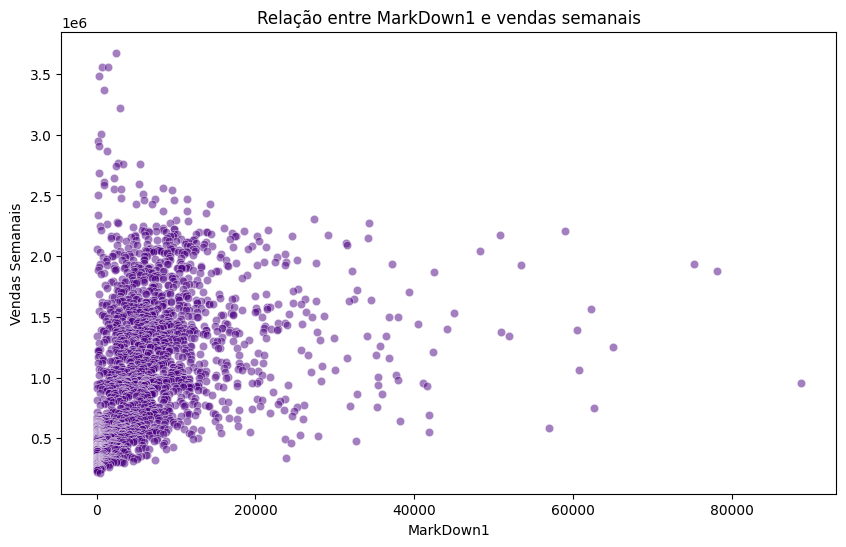

In [411]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_venda_markdown_periodo, x="MarkDown1", y="Weekly_Sales", alpha=0.5, color="indigo")
plt.title("Relação entre MarkDown1 e vendas semanais")
plt.xlabel("MarkDown1")
plt.ylabel("Vendas Semanais")
plt.show()

O gráfico de dispersão indica uma associação positiva entre MarkDown1 e as vendas semanais, porém com elevada dispersão entre as observações. Isso é consistente com a correlação de aproximadamente 0,32, sugerindo que valores maiores de MarkDown1 tendem a estar associados a maiores volumes de vendas, mas a variável isoladamente não explica grande parte da variação observada.

In [412]:
df_venda_markdown_periodo["MarkDown1"].describe()

,MarkDown1
count,2280.000000
mean,6855.587430
std,8183.310015
min,0.270000
25%,1679.190000
50%,4972.590000
75%,8873.582500
max,88646.760000


In [413]:
import plotly.express as px

fig = px.box(
    df_venda_markdown_periodo,
    x="MarkDown1",
    title="Distribuição dos valores de MarkDown1"
)

fig.show()

### 📌 Identificação de Outliers pelo Método IQR

O **boxplot** utiliza os quartis da distribuição para identificar valores potencialmente extremos.

Os principais valores são:

- **Q1 (25%)**: 25% dos dados estão abaixo desse valor.
- **Q2 (50%) ou Mediana**: divide os dados ao meio — 50% abaixo e 50% acima.
- **Q3 (75%)**: 75% dos dados estão abaixo desse valor.

A distância entre **Q1 e Q3** é chamada de **IQR (Interquartile Range / Intervalo Interquartil)**.

$$
IQR = Q3 - Q1
$$

O critério mais utilizado considera como potenciais outliers os valores que estão fora dos seguintes limites:

$$
Limite\ Inferior = Q1 - 1.5 \times IQR
$$

$$
Limite\ Superior = Q3 + 1.5 \times IQR
$$

---

#### 🔎 Exemplo aplicado ao `MarkDown1`

A análise descritiva apresentou:

| Medida | Valor |
|---|---:|
| Q1 (25%) | 1.679,19 |
| Mediana (50%) | 4.972,59 |
| Q3 (75%) | 8.873,58 |
| Média | 6.855,59 |
| Máximo | 88.646,76 |

Primeiro, calcula-se o IQR:

$$
IQR = 8.873,58 - 1.679,19
$$

$$
IQR = 7.194,39
$$

Em seguida, calculam-se os limites.

**Limite inferior:**

$$
1.679,19 - (1.5 \times 7.194,39)
$$

$$
Limite\ Inferior \approx -9.112,40
$$

**Limite superior:**

$$
8.873,58 + (1.5 \times 7.194,39)
$$

$$
Limite\ Superior \approx 19.665,17
$$

Portanto, pelo critério do IQR, valores de `MarkDown1` acima de aproximadamente **19.665** são classificados como potenciais outliers.

Como o limite inferior calculado é negativo e o menor valor observado de `MarkDown1` é positivo, não foram identificados outliers inferiores nesse caso.

---

#### 🧠 Como interpretar?

Um **outlier não significa necessariamente um erro**.

Ele apenas indica que determinada observação está distante da região central da distribuição.

Um valor extremo pode representar:

- erro de coleta ou registro;
- comportamento legítimo;
- evento excepcional;
- característica específica do negócio;
- informação importante para a análise.

Por isso, **não devemos remover automaticamente os outliers**.

Primeiro devemos investigar o contexto e verificar como esses valores influenciam a análise.

Neste projeto, os valores extremos de `MarkDown1` foram mantidos no conjunto original. Uma análise adicional sem esses valores foi realizada apenas como **análise de sensibilidade**, permitindo comparar os resultados com e sem os potenciais outliers.

---

#### 📊 Resumo do cálculo

**1. Encontrar Q1 e Q3**

$$
Q1 = Percentil\ 25\%
$$

$$
Q3 = Percentil\ 75\%
$$

**2. Calcular o IQR**

$$
IQR = Q3 - Q1
$$

**3. Calcular os limites**

$$
Limite\ Inferior = Q1 - 1.5 \times IQR
$$

$$
Limite\ Superior = Q3 + 1.5 \times IQR
$$

**4. Identificar os potenciais outliers**

$$
Valor < Limite\ Inferior
$$

ou

$$
Valor > Limite\ Superior
$$

> **Importante:** o boxplot identifica valores estatisticamente atípicos, mas não determina se esses valores devem ser excluídos. A decisão depende do contexto dos dados e do problema de negócio.

In [414]:
df_sem_outlier = df_venda_markdown_periodo[df_venda_markdown_periodo["MarkDown1"] < 19665]
df_sem_outlier

,Store,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Year,Month,Day,HasMarkDown
3,4,2011-12-23,3676388.98,35.92,3.103,2461.94,69.05,2938.24,52.00,4396.76,129.984548,5.143,False,2011,12,23,True
5,13,2011-12-23,3556766.03,24.76,3.186,686.24,193.26,2971.53,239.78,3567.03,129.984548,6.392,False,2011,12,23,True
6,20,2011-12-23,3555371.03,40.19,3.389,1483.17,80.15,2145.46,38.97,4180.29,212.236040,7.082,False,2011,12,23,True
8,10,2011-12-23,3487986.89,48.36,3.541,300.02,77.73,2432.01,108.37,4078.21,129.984548,7.874,False,2011,12,23,True
10,14,2011-12-23,3369068.99,42.27,3.389,924.14,112.73,2127.77,80.02,4638.81,188.929975,8.523,False,2011,12,23,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6397,33,2012-02-24,242526.70,59.41,3.950,577.17,268.61,NaN,2.61,1653.57,130.550207,7.603,False,2012,2,24,True
6411,33,2012-08-31,237129.81,94.55,3.886,119.39,NaN,NaN,9.70,1547.92,130.885355,7.147,False,2012,8,31,True
6413,33,2012-01-27,236920.49,56.33,3.675,12.60,12.47,3.38,NaN,375.54,130.314452,7.603,False,2012,1,27,True
6430,33,2011-12-02,220060.35,59.12,3.701,0.50,NaN,4.00,NaN,1280.77,129.845967,8.010,False,2011,12,2,True


In [415]:
df_sem_outlier[["Weekly_Sales", "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]].corr()

,Weekly_Sales,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
Weekly_Sales,1.000000,0.437628,0.091366,0.204071,0.229765,0.296681
MarkDown1,0.437628,1.000000,0.063734,-0.145137,0.587213,0.221990
MarkDown2,0.091366,0.063734,1.000000,-0.049666,-0.014370,-0.008575
MarkDown3,0.204071,-0.145137,-0.049666,1.000000,-0.100340,-0.020898
MarkDown4,0.229765,0.587213,-0.014370,-0.100340,1.000000,0.140730
MarkDown5,0.296681,0.221990,-0.008575,-0.020898,0.140730,1.000000


A análise de sensibilidade mostrou que a associação entre MarkDown1 e as vendas semanais não é explicada pelos valores extremos da variável. A correlação passou de aproximadamente 0,32 no conjunto completo para 0,44 ao considerar valores de MarkDown1 até o limite superior definido pelo método do IQR. Isso sugere uma associação positiva mais consistente na faixa central da distribuição, enquanto valores excepcionalmente elevados de MarkDown1 não apresentam crescimento proporcional das vendas.

In [416]:
# Existe associação entre as condições externas e o volume semanal de vendas de cada loja?

df_venda_markdown_periodo[["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"]].corr()

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment
Weekly_Sales,1.000000,-0.078732,-0.035428,-0.070960,-0.103957
Temperature,-0.078732,1.000000,0.250179,0.179417,0.014947
Fuel_Price,-0.035428,0.250179,1.000000,-0.408655,0.252653
CPI,-0.070960,0.179417,-0.408655,1.000000,-0.274501
Unemployment,-0.103957,0.014947,0.252653,-0.274501,1.000000


### Relação entre Vendas e Variáveis Externas

Para avaliar a associação entre as vendas semanais e as variáveis externas, foi utilizada a **correlação de Pearson**.

A análise foi realizada no nível **Loja × Semana**, evitando que as variáveis externas fossem repetidas para cada departamento da mesma loja.

Os resultados encontrados para `Weekly_Sales` foram:

| Variável | Correlação | Interpretação |
|---|---:|---|
| Temperature | -0,079 | Correlação negativa muito fraca |
| Fuel_Price | -0,035 | Correlação praticamente inexistente |
| CPI | -0,071 | Correlação negativa muito fraca |
| Unemployment | -0,104 | Correlação negativa fraca |

Nenhuma das variáveis externas apresentou **associação linear expressiva** com o volume semanal de vendas.

`Unemployment` apresentou a maior correlação em módulo (`r ≈ -0,10`), porém ainda representa uma associação linear fraca. `Fuel_Price`, por sua vez, apresentou correlação muito próxima de zero.

### Interpretação

A correlação de Pearson mede especificamente a **relação linear** entre duas variáveis. Portanto, valores próximos de zero não significam necessariamente que não exista qualquer relação entre elas, mas indicam que **não foi identificada uma relação linear relevante**.

Além disso, correlação não implica causalidade. Dessa forma, os resultados não permitem afirmar que alterações em temperatura, combustível, CPI ou desemprego provoquem mudanças nas vendas.

**Conclusão:** no nível agregado de loja por semana, as variáveis externas analisadas isoladamente apresentam baixa associação linear com `Weekly_Sales`, indicando que outros fatores provavelmente possuem maior relevância para explicar as variações observadas nas vendas.

## Feature Engineering para previsão

In [417]:
df_features["Week"] = df_features["Date"].dt.isocalendar().week.astype(int)
df_features[["Date", "Year", "Month", "Week"]].head()

,Date,Year,Month,Week
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9


In [418]:
print(df_train["Date"].min())
print(df_train["Date"].max())
print(df_train["Date"].nunique())

2010-02-05 00:00:00
2012-10-26 00:00:00
143


In [419]:
# Ordenando os dados para garantir que a linha do tempo esteja correta
df_merge = df_merge.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

In [420]:
import numpy as np

# 1. Extraindo a semana do ano diretamente no df_merge (antes eu fiz no df_features)
df_merge['Week'] = df_merge['Date'].dt.isocalendar().week.astype(int)

# 2. Transformação cíclica para o Mês (1 a 12)
df_merge['Month_Sin'] = np.sin(2 * np.pi * df_merge['Month'] / 12)
df_merge['Month_Cos'] = np.cos(2 * np.pi * df_merge['Month'] / 12)

# 3. Transformação cíclica para a Semana do Ano (1 a 52)
df_merge['Week_Sin'] = np.sin(2 * np.pi * df_merge['Week'] / 52)
df_merge['Week_Cos'] = np.cos(2 * np.pi * df_merge['Week'] / 52)

In [421]:
# Criando colunas numéricas (0 ou 1) para cada feriado principal do Walmart
# O Super Bowl acontece em Fevereiro (Mês 2)
df_merge['Is_SuperBowl'] = ((df_merge['IsHoliday'] == True) & (df_merge['Month'] == 2)).astype(int)

# O Labor Day acontece em Setembro (Mês 9)
df_merge['Is_LaborDay'] = ((df_merge['IsHoliday'] == True) & (df_merge['Month'] == 9)).astype(int)

# O Thanksgiving acontece em Novembro (Mês 11)
df_merge['Is_Thanksgiving'] = ((df_merge['IsHoliday'] == True) & (df_merge['Month'] == 11)).astype(int)

# O Natal acontece em Dezembro (Mês 12)
df_merge['Is_Christmas'] = ((df_merge['IsHoliday'] == True) & (df_merge['Month'] == 12)).astype(int)

# Como já extraímos a informação detalhada, podemos descartar a coluna original
df_merge.drop(columns=['IsHoliday'], inplace=True)

In [422]:
# Vendas de 1 semana atrás
df_merge['Lag_1_Week'] = (
    df_merge.groupby(['Store', 'Dept'])['Weekly_Sales']
    .shift(1)
)

# Vendas de 4 semanas atrás
df_merge['Lag_4_Weeks'] = (
    df_merge.groupby(['Store', 'Dept'])['Weekly_Sales']
    .shift(4)
)

# Média das últimas 4 semanas
df_merge['Rolling_Mean_4_Weeks'] = (
    df_merge.groupby(['Store', 'Dept'])['Weekly_Sales']
    .transform(
        lambda x: x.shift(1).rolling(window=4, min_periods=1).mean()
    )
)

In [423]:
# Converter os tipos de loja em valores numéricos
type_mapping = {'A': 3, 'B': 2, 'C': 1}

df_merge['Type_Encoded'] = df_merge['Type'].map(type_mapping)

# Remover a coluna original de texto
df_merge.drop(columns=['Type'], inplace=True)

In [424]:
df_merge

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,Week_Sin,Week_Cos,Is_SuperBowl,Is_LaborDay,Is_Thanksgiving,Is_Christmas,Lag_1_Week,Lag_4_Weeks,Rolling_Mean_4_Weeks,Type_Encoded
0,1,1,2010-02-05,24924.50,42.31,2.572,NaN,NaN,NaN,NaN,...,0.568065,8.229839e-01,0,0,0,0,NaN,NaN,NaN,3
1,1,1,2010-02-12,46039.49,38.51,2.548,NaN,NaN,NaN,NaN,...,0.663123,7.485107e-01,1,0,0,0,24924.50,NaN,24924.500000,3
2,1,1,2010-02-19,41595.55,39.93,2.514,NaN,NaN,NaN,NaN,...,0.748511,6.631227e-01,0,0,0,0,46039.49,NaN,35481.995000,3
3,1,1,2010-02-26,19403.54,46.63,2.561,NaN,NaN,NaN,NaN,...,0.822984,5.680647e-01,0,0,0,0,41595.55,NaN,37519.846667,3
4,1,1,2010-03-05,21827.90,46.50,2.625,NaN,NaN,NaN,NaN,...,0.885456,4.647232e-01,0,0,0,0,19403.54,24924.50,32990.770000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,64.88,3.997,4556.61,20.64,1.50,1601.01,...,-1.000000,-1.836970e-16,0,0,0,0,467.30,346.04,442.935000,2
421566,45,98,2012-10-05,628.10,64.89,3.985,5046.74,NaN,18.82,2253.43,...,-0.992709,1.205367e-01,0,0,0,0,508.37,352.44,483.517500,2
421567,45,98,2012-10-12,1061.02,54.47,4.000,1956.28,NaN,7.89,599.32,...,-0.970942,2.393157e-01,0,0,0,0,628.10,605.96,552.432500,2
421568,45,98,2012-10-19,760.01,56.47,3.969,2004.02,NaN,3.18,437.73,...,-0.935016,3.546049e-01,0,0,0,0,1061.02,467.30,666.197500,2


In [425]:
df_merge.isna().sum().sort_values(ascending=False)

,0
MarkDown2,310322
MarkDown4,286603
MarkDown3,284479
MarkDown1,270889
MarkDown5,270138
Lag_4_Weeks,13134
Lag_1_Week,3331
Rolling_Mean_4_Weeks,3331
Fuel_Price,0
Weekly_Sales,0


In [426]:
df_merge.isna().mean().sort_values(ascending=False) * 100

,0
MarkDown2,73.611025
MarkDown4,67.984676
MarkDown3,67.480845
MarkDown1,64.257181
MarkDown5,64.079038
Lag_4_Weeks,3.115497
Lag_1_Week,0.790142
Rolling_Mean_4_Weeks,0.790142
Fuel_Price,0.000000
Weekly_Sales,0.000000


In [427]:
# Limpeza final e definição de X e Y
# 1. Remover as linhas com valores nulos gerados pelos lags
df_model = df_merge.dropna(subset=["Lag_1_Week", "Lag_4_Weeks", "Rolling_Mean_4_Weeks"]).copy()

# Lag_1_Week → não existe venda da semana anterior para a primeira observação.
# Lag_4_Weeks → não existe histórico de 4 semanas nas primeiras observações.
# Rolling_Mean_4_Weeks → também precisa de histórico anterior.

# 2. Separar os preditores (X) da variável alvo (y)
# Descartamos 'Weekly_Sales' porque é o que queremos prever
# Descartamos 'Date' porque os modelos não processam o formato datetime nativo (já extraímos o que importava)
cols_to_drop = [
    "Weekly_Sales",
    "Date",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

X = df_model.drop(columns=cols_to_drop)
y = df_model["Weekly_Sales"]

In [428]:
print("Primeira data do df_model:", df_model["Date"].min())
print("Última data do df_model:", df_model["Date"].max())
print("Quantidade de semanas:", df_model["Date"].nunique())

print("\nNAs nas variáveis que entrarão no modelo:")
print(X.isna().sum().sort_values(ascending=False))

Primeira data do df_model: 2010-03-05 00:00:00
Última data do df_model: 2012-10-26 00:00:00
Quantidade de semanas: 139

NAs nas variáveis que entrarão no modelo:
Store                   0
Dept                    0
Temperature             0
Fuel_Price              0
CPI                     0
Unemployment            0
Year                    0
Month                   0
Day                     0
Size                    0
HasMarkDown             0
Week                    0
Month_Sin               0
Month_Cos               0
Week_Sin                0
Week_Cos                0
Is_SuperBowl            0
Is_LaborDay             0
Is_Thanksgiving         0
Is_Christmas            0
Lag_1_Week              0
Lag_4_Weeks             0
Rolling_Mean_4_Weeks    0
Type_Encoded            0
dtype: int64


In [429]:
# Definir as últimas 10 semanas como período de validação

datas = df_model["Date"].drop_duplicates().sort_values()

datas_validacao = datas.iloc[-10:]

data_corte = datas_validacao.iloc[0]

df_treino = df_model[df_model["Date"] < data_corte]
df_validacao = df_model[df_model["Date"] >= data_corte]

X_train = df_treino.drop(columns=cols_to_drop)
y_train = df_treino["Weekly_Sales"]

X_val = df_validacao.drop(columns=cols_to_drop)
y_val = df_validacao["Weekly_Sales"]

In [430]:
print("Treino:")
print("Primeira data:", df_treino["Date"].min())
print("Última data:", df_treino["Date"].max())
print("Semanas:", df_treino["Date"].nunique())
print("Linhas:", len(X_train))

print("\nValidação:")
print("Primeira data:", df_validacao["Date"].min())
print("Última data:", df_validacao["Date"].max())
print("Semanas:", df_validacao["Date"].nunique())
print("Linhas:", len(X_val))

Treino:
Primeira data: 2010-03-05 00:00:00
Última data: 2012-08-17 00:00:00
Semanas: 129
Linhas: 378808

Validação:
Primeira data: 2012-08-24 00:00:00
Última data: 2012-10-26 00:00:00
Semanas: 10
Linhas: 29628


In [431]:
print("NAs no treino:", X_train.isna().sum().sum())
print("NAs na validação:", X_val.isna().sum().sum())

NAs no treino: 0
NAs na validação: 0


In [432]:
# Baseline: utilizar a venda da semana anterior como previsão
baseline_preds = X_val['Lag_1_Week']

baseline_mae = mean_absolute_error(y_val, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_preds))
baseline_r2 = r2_score(y_val, baseline_preds)

print("--- Baseline ---")
print(f"MAE:  US$ {baseline_mae:,.2f}")
print(f"RMSE: US$ {baseline_rmse:,.2f}")
print(f"R²:   {baseline_r2:.4f}")

--- Baseline ---
MAE:  US$ 1,546.34
RMSE: US$ 3,557.42
R²:   0.9734


In [433]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# 1. Inicializar os modelos
# random_state garante que o resultado será o mesmo sempre que rodar o código
# n_jobs=-1 utiliza todos os núcleos do processador para acelerar o treino
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)

# 2. Treinar os modelos com os dados históricos (X_train, y_train)
print("A treinar o Random Forest (pode demorar alguns minutos)...")
rf_model.fit(X_train, y_train)

print("A treinar o XGBoost...")
xgb_model.fit(X_train, y_train)

# 3. Gerar previsões para o período de validação (futuro recente)
rf_preds = rf_model.predict(X_val)
xgb_preds = xgb_model.predict(X_val)

# 4. Calcular as métricas de erro
rf_mae = mean_absolute_error(y_val, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_preds))
rf_r2 = r2_score(y_val, rf_preds)

xgb_mae = mean_absolute_error(y_val, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
xgb_r2 = r2_score(y_val, xgb_preds)

# 5. Apresentar a comparação
print("\n--- Random Forest ---")
print(f"MAE:  US$ {rf_mae:,.2f}")
print(f"RMSE: US$ {rf_rmse:,.2f}")
print(f"R²:   {rf_r2:.4f}")

print("\n--- XGBoost ---")
print(f"MAE:  US$ {xgb_mae:,.2f}")
print(f"RMSE: US$ {xgb_rmse:,.2f}")
print(f"R²:   {xgb_r2:.4f}")

A treinar o Random Forest (pode demorar alguns minutos)...
A treinar o XGBoost...

--- Random Forest ---
MAE:  US$ 1,294.50
RMSE: US$ 2,783.09
R²:   0.9837

--- XGBoost ---
MAE:  US$ 1,349.22
RMSE: US$ 2,876.81
R²:   0.9826


### 📊 Comparação com o Baseline

O baseline, que utiliza as vendas da semana anterior como previsão, apresentou **MAE de US\$ 1.546,34**, **RMSE de US\$ 3.557,42** e **R² de 0,9734**.

Apesar do bom desempenho da abordagem simples, o **Random Forest apresentou os melhores resultados**, com **MAE de US\$ 1.294,50**, **RMSE de US\$ 2.783,09** e **R² de 0,9837**.

Em relação ao baseline, o Random Forest reduziu o **MAE em aproximadamente 16,3%** e o **RMSE em 21,8%**, indicando que o modelo conseguiu melhorar as previsões em relação ao uso exclusivo das vendas da semana anterior.

In [434]:
# Adicionar as previsões do melhor modelo aos dados de validação
resultados = X_val.copy()

resultados['Venda_Real'] = y_val
resultados['Previsao'] = rf_preds

# Calcular o erro absoluto de cada previsão
resultados['Erro_Absoluto'] = abs(
    resultados['Venda_Real'] - resultados['Previsao']
)

# Identificar os departamentos com maior erro médio
erros_por_dept = (
    resultados.groupby('Dept')['Erro_Absoluto']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

# Identificar as lojas com maior erro médio
erros_por_loja = (
    resultados.groupby('Store')['Erro_Absoluto']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

print("--- Top 5 Departamentos mais difíceis de prever ($) ---")
print(erros_por_dept)

print("\n--- Top 5 Lojas mais difíceis de prever ($) ---")
print(erros_por_loja)

--- Top 5 Departamentos mais difíceis de prever ($) ---
Dept
38    5311.895184
72    5244.879458
3     4524.421309
92    3628.467615
9     3436.306042
Name: Erro_Absoluto, dtype: float64

--- Top 5 Lojas mais difíceis de prever ($) ---
Store
4     2149.449016
13    2078.592901
20    2043.797174
14    2037.655568
17    1966.792632
Name: Erro_Absoluto, dtype: float64


In [435]:
# Verificar quais feriados aparecem no período de validação

print("Super Bowl:", resultados['Is_SuperBowl'].sum())
print("Labor Day:", resultados['Is_LaborDay'].sum())
print("Thanksgiving:", resultados['Is_Thanksgiving'].sum())
print("Christmas:", resultados['Is_Christmas'].sum())

Super Bowl: 0
Labor Day: 2963
Thanksgiving: 0
Christmas: 0


In [436]:
# Separar registros do Labor Day
labor_day = resultados[
    resultados['Is_LaborDay'] == 1
]

# Separar semanas sem os feriados analisados
semanas_normais = resultados[
    (resultados['Is_SuperBowl'] == 0) &
    (resultados['Is_LaborDay'] == 0) &
    (resultados['Is_Thanksgiving'] == 0) &
    (resultados['Is_Christmas'] == 0)
]

# Calcular o erro médio
erro_labor_day = labor_day['Erro_Absoluto'].mean()
erro_normal = semanas_normais['Erro_Absoluto'].mean()
aumento_erro = ((erro_labor_day - erro_normal) / erro_normal) * 100

print("--- Comparação do Erro Médio ---")
print(f"Labor Day: R$ {erro_labor_day:,.2f}")
print(f"Semanas normais: R$ {erro_normal:,.2f}")
print(f"Aumento do erro no Labor Day: {aumento_erro:.1f}%")

--- Comparação do Erro Médio ---
Labor Day: R$ 1,758.38
Semanas normais: R$ 1,242.96
Aumento do erro no Labor Day: 41.5%


### 📌 Impacto do Labor Day nas Previsões

O modelo apresentou um erro médio de **US\$ 1.758,38** nos registros associados ao Labor Day, enquanto nas semanas normais o erro médio foi de **US\$ 1.242,96**.

Isso representa um erro aproximadamente **41,5% maior durante o Labor Day**, indicando que o modelo apresenta maior dificuldade para prever as vendas durante esse período.

Esse resultado mostra que, apesar do bom desempenho geral do Random Forest, períodos associados a eventos especiais podem apresentar padrões de vendas mais difíceis de prever.

# 📌 Conclusões

O projeto teve como objetivo analisar o histórico de vendas das lojas do Walmart e avaliar a possibilidade de prever as vendas semanais utilizando informações históricas, características das lojas e variáveis relacionadas ao período analisado.

## 🔎 Principais resultados da análise

A análise exploratória mostrou diferenças relevantes no comportamento das vendas entre **lojas e departamentos**. Lojas de maior porte apresentaram, de forma geral, maiores volumes médios de vendas, enquanto alguns departamentos se destacaram tanto pelo volume vendido quanto pelas diferenças de comportamento entre as lojas.

Na análise temporal, foram identificadas oscilações nas vendas ao longo do período, com destaque para picos próximos aos **feriados de fim de ano**. Não foi observada, entretanto, uma tendência contínua de crescimento ou queda durante todo o período analisado.

As variáveis externas, como **temperatura, preço dos combustíveis, CPI e desemprego**, apresentaram correlações lineares fracas com as vendas semanais. Já as variáveis de **MarkDown** também apresentaram relações limitadas quando analisadas individualmente, indicando que o comportamento das vendas não pode ser explicado por uma única variável isolada.

## 🤖 Modelagem e previsão

Para respeitar a natureza temporal dos dados, as últimas **10 semanas** foram utilizadas como conjunto de validação, mantendo os dados anteriores para treinamento.

Também foi criado um **baseline**, utilizando as vendas da semana anterior como previsão. Essa abordagem simples apresentou:

- **MAE:** US\$ 1.546,34
- **RMSE:** US\$ 3.557,42
- **R²:** 0,9734

Entre os modelos de Machine Learning avaliados, o **Random Forest apresentou o melhor desempenho**, com:

- **MAE:** US\$ 1.294,50
- **RMSE:** US\$ 2.783,09
- **R²:** 0,9837

Em comparação ao baseline, o Random Forest reduziu o **MAE em aproximadamente 16,3%** e o **RMSE em aproximadamente 21,8%**, demonstrando ganho nas previsões em relação ao uso exclusivo das vendas da semana anterior.

O XGBoost também apresentou bom desempenho, porém ficou ligeiramente abaixo do Random Forest nas métricas avaliadas.

## ⚠️ Análise dos erros

Apesar do bom desempenho geral, o modelo não apresentou a mesma precisão em todas as situações.

Os **departamentos 38, 72 e 3** apresentaram os maiores erros absolutos médios, enquanto as **lojas 4, 13 e 20** ficaram entre aquelas com maiores erros de previsão.

Também foi identificado que, durante os registros associados ao **Labor Day**, o erro absoluto médio foi de **US\$ 1.758,38**, contra **US\$ 1.242,96** nas semanas normais. Isso representa um erro aproximadamente **41,5% maior**, indicando maior dificuldade do modelo para prever as vendas nesse período.

## 💡 Considerações finais

Os resultados mostram que o histórico recente de vendas possui forte poder preditivo, algo evidenciado pelo bom desempenho do próprio baseline. Ainda assim, o Random Forest conseguiu melhorar as previsões ao utilizar conjuntamente as demais características disponíveis.

Ao mesmo tempo, a análise dos erros mostra que um bom desempenho geral não significa que o modelo seja igualmente preciso para todas as lojas, departamentos ou períodos especiais.

Dessa forma, o projeto demonstra a importância de combinar **análise exploratória, Feature Engineering, validação temporal, comparação com um baseline e análise dos erros**, em vez de avaliar a qualidade de um modelo apenas por uma única métrica.